Импорт библиотек и загрузка данных

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx
#загрузка данных
all_data = pd.read_csv('groceries - groceries.csv')
print(all_data)

      Item(s)               Item 1               Item 2            Item 3  \
0           4         citrus fruit  semi-finished bread         margarine   
1           3       tropical fruit               yogurt            coffee   
2           1           whole milk                  NaN               NaN   
3           4            pip fruit               yogurt      cream cheese   
4           4     other vegetables           whole milk    condensed milk   
...       ...                  ...                  ...               ...   
9830       17              sausage              chicken              beef   
9831        1    cooking chocolate                  NaN               NaN   
9832       10              chicken         citrus fruit  other vegetables   
9833        4  semi-finished bread        bottled water              soda   
9834        5              chicken       tropical fruit  other vegetables   

                        Item 4         Item 5          Item 6  \
0         

Визуализация транзакций

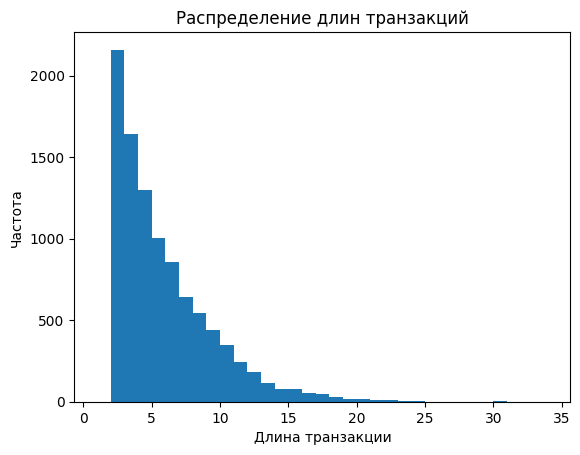

In [2]:
#Анализ транзакций
transaction_lengths = all_data.notnull().sum(axis=1)
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths) + 2))
plt.xlabel('Длина транзакции')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.show()

Очистка данных

In [ ]:
#Очистка данных
np_data = all_data.to_numpy()
np_data = [[elem for elem in row[1:] if isinstance(elem,str)] for row in np_data]

#Список уникальных товаров
unique_items = set()
for row in np_data:
    for elem in row:
        unique_items.add(elem)
print(unique_items)
te = TransactionEncoder()
te_ary = te.fit(np_data).transform(np_data)
data = pd.DataFrame(te_ary, columns=te.columns_)

{'preservation products', 'cooking chocolate', 'grapes', 'red/blush wine', 'newspapers', 'rubbing alcohol', 'beef', 'frozen chicken', 'white wine', 'herbs', 'misc. beverages', 'light bulbs', 'liver loaf', 'finished products', 'baby food', 'make up remover', 'sweet spreads', 'curd cheese', 'sausage', 'pork', 'roll products', 'flower soil/fertilizer', 'hamburger meat', 'brown bread', 'whipped/sour cream', 'canned beer', 'tidbits', 'cleaner', 'bags', 'rolls/buns', 'cereals', 'specialty chocolate', 'soft cheese', 'ketchup', 'processed cheese', 'chewing gum', 'soap', 'other vegetables', 'specialty cheese', 'skin care', 'syrup', 'canned vegetables', 'frozen dessert', 'hygiene articles', 'onions', 'organic sausage', 'domestic eggs', 'female sanitary products', 'seasonal products', 'instant coffee', 'butter milk', 'pasta', 'soups', 'dessert', 'pastry', 'specialty vegetables', 'dog food', 'berries', 'toilet cleaner', 'bottled water', 'whole milk', 'frozen vegetables', 'salt', 'detergent', 'pet 

In [31]:
#Алгоритм FPG
df1 = fpgrowth(data, min_support=0.03, use_colnames = True)
print(df1)
rules = association_rules(df1, metric = "confidence", min_threshold = 0.3)
print(rules)

     support                             itemsets
0   0.082766                       (citrus fruit)
1   0.058566                          (margarine)
2   0.139502                             (yogurt)
3   0.104931                     (tropical fruit)
4   0.058058                             (coffee)
..       ...                                  ...
58  0.033249                 (whole milk, pastry)
59  0.047382  (root vegetables, other vegetables)
60  0.048907        (whole milk, root vegetables)
61  0.030605                (rolls/buns, sausage)
62  0.032232     (whole milk, whipped/sour cream)

[63 rows x 2 columns]
             antecedents         consequents  antecedent support  \
0         (citrus fruit)        (whole milk)            0.082766   
1               (yogurt)        (whole milk)            0.139502   
2               (yogurt)  (other vegetables)            0.139502   
3       (tropical fruit)  (other vegetables)            0.104931   
4       (tropical fruit)        (whol

In [ ]:
#Алгоритм Apriori
#df1 = apriori(data, min_support=0.03, use_colnames = True)
#print(df1)
#rules = association_rules(df1, metric = "confidence", min_threshold = 0.3)
#print(rules)

     support                          itemsets
0   0.033452                        (UHT-milk)
1   0.052466                            (beef)
2   0.033249                         (berries)
3   0.080529                    (bottled beer)
4   0.110524                   (bottled water)
..       ...                               ...
58  0.048907     (whole milk, root vegetables)
59  0.040061                (soda, whole milk)
60  0.042298      (tropical fruit, whole milk)
61  0.032232  (whole milk, whipped/sour cream)
62  0.056024              (yogurt, whole milk)

[63 rows x 2 columns]
             antecedents         consequents  antecedent support  \
0        (bottled water)        (whole milk)            0.110524   
1         (citrus fruit)        (whole milk)            0.082766   
2      (root vegetables)  (other vegetables)            0.108998   
3       (tropical fruit)  (other vegetables)            0.104931   
4     (other vegetables)        (whole milk)            0.193493   
5    

     support          itemsets
5   0.255516        whole milk
8   0.193493  other vegetables
11  0.183935        rolls/buns
19  0.174377              soda
2   0.139502            yogurt
14  0.110524     bottled water
26  0.108998   root vegetables
3   0.104931    tropical fruit
31  0.098526     shopping bags
30  0.093950           sausage


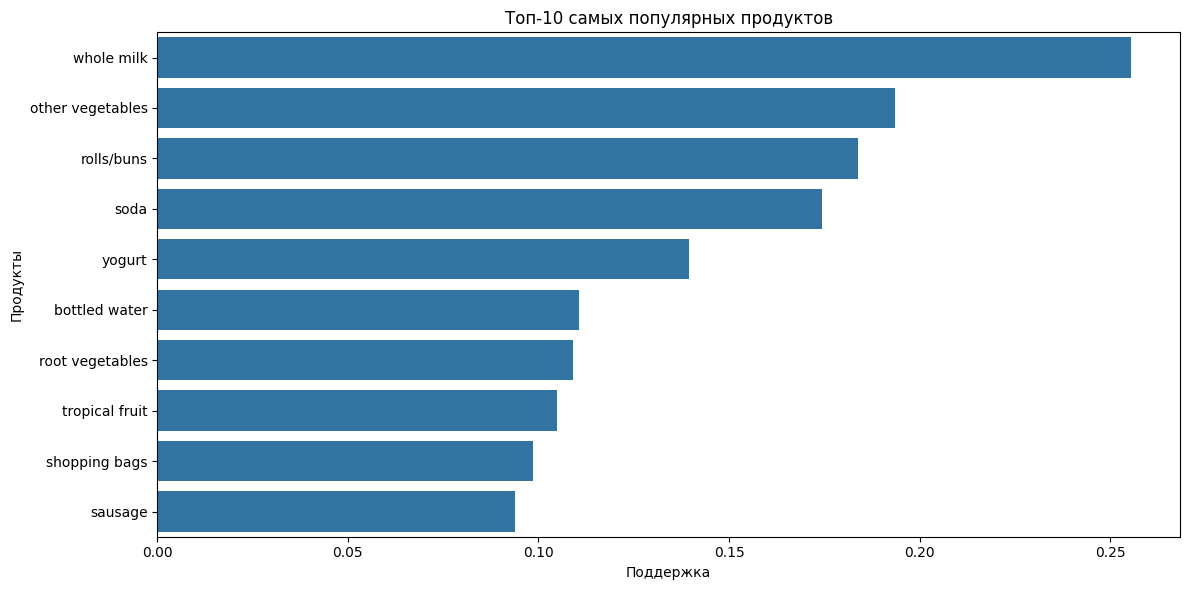

In [32]:
#Поддержка
df1['itemsets'] = df1['itemsets'].apply(lambda x: ', '.join(list(x)))
top_products = df1.sort_values(by='support', ascending=False).head(10)
print(top_products)
plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title('Топ-10 самых популярных продуктов')
plt.xlabel('Поддержка')
plt.ylabel('Продукты')
plt.tight_layout()
plt.show()
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

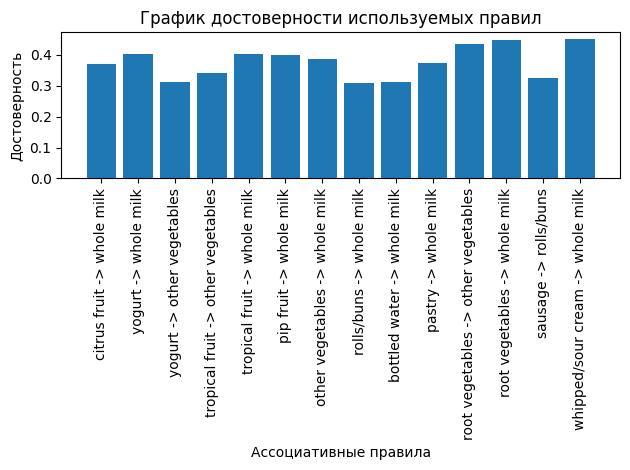

In [33]:
#График достоверности используемых правил
products_1 = rules["antecedents"].tolist()
products_2 = rules["consequents"].tolist()
confidence = rules["confidence"].tolist()
rules_labels = [f"{product1} -> {product2}" for product1, product2 in zip(products_1, products_2)]
plt.bar(rules_labels, confidence)
plt.xlabel("Ассоциативные правила")
plt.ylabel("Достоверность")
plt.title("График достоверности используемых правил")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

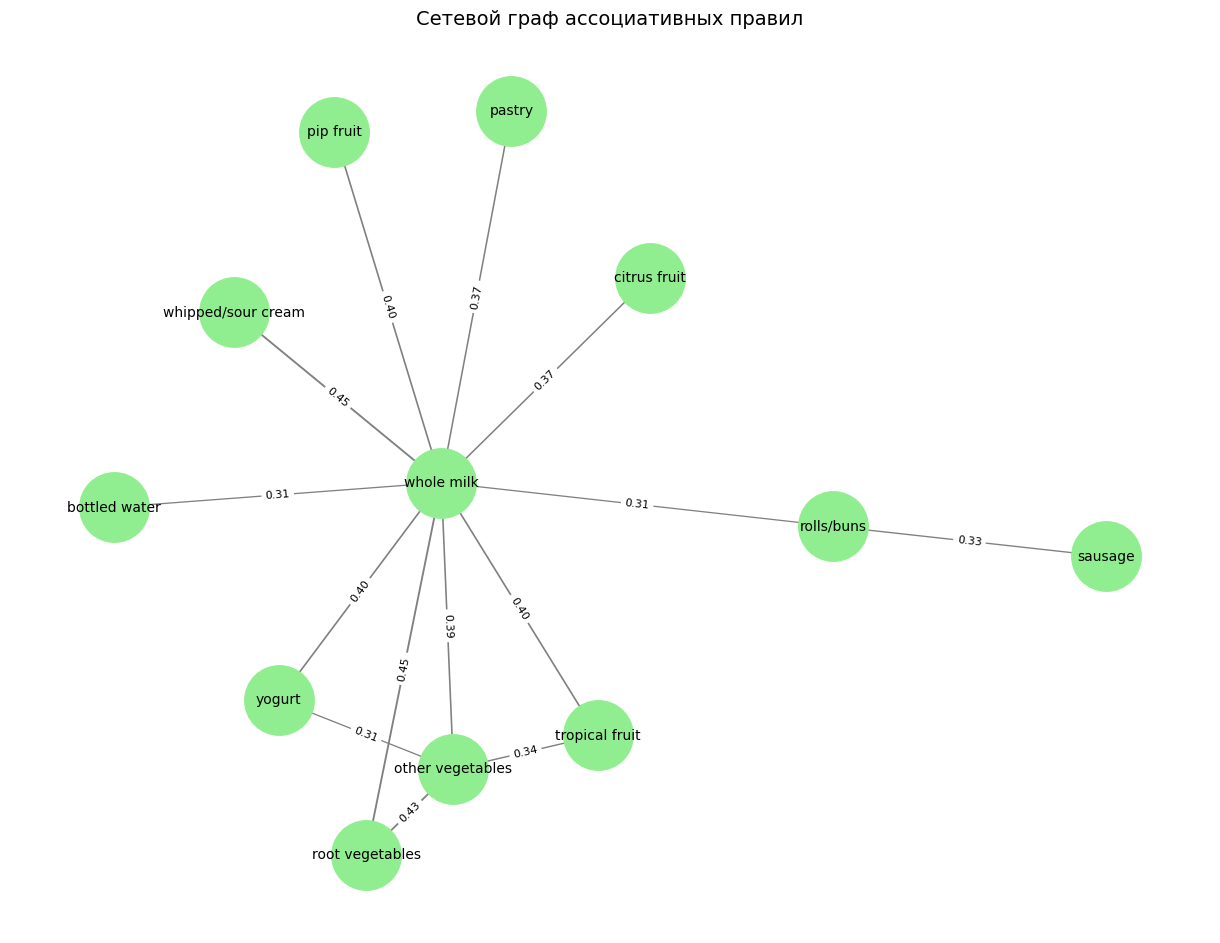

In [34]:
G = nx.Graph()
for index, row in rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, k=1.0, iterations=200, seed=42)
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    node_color='lightgreen',
    font_size=10,
    edge_color='gray',
    width=[w * 3 for w in weights]
)
edge_labels = {k: f"{v:.2f}" for k, v in nx.get_edge_attributes(G, 'weight').items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title('Сетевой граф ассоциативных правил', fontsize=14)
plt.show()